<a href="https://colab.research.google.com/github/pandita56666/SPIS-ML-Seismic-Performance-Intelligent-System/blob/main/GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Upload drive files
from google.colab import files
from google.colab import drive

drive.mount ('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#General libreries
from PIL import Image  # Library for image processing
import pandas as pd  # Library for data manipulation
import matplotlib.pyplot as plt  # Library for data visualization
import datetime  # Library for handling dates and times
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta  # Additional functionality for date manipulation


In [ ]:
rutaA='/content/database (1).csv'#Route to irradiance data  SOLCAST= pd.read_csv(rutaA)
tsunami= pd.read_csv(rutaA)

In [ ]:
tsunami["Magnitude"] = pd.to_numeric(tsunami["Magnitude"], errors='coerce')


In [ ]:
nan_totales = tsunami.Magnitude.isna().sum().sum()

print(f"El dataframe tiene {nan_totales} valores NaN.")

#cambiar el nombre de la columna de un df

El dataframe tiene 0 valores NaN.


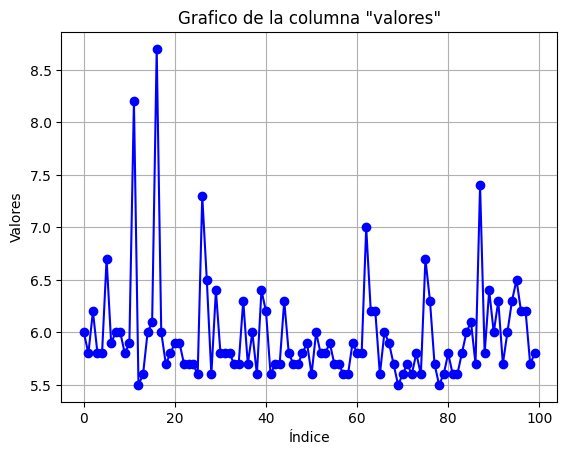

In [ ]:
plt.plot(tsunami['Magnitude'].iloc[0:100], marker='o', linestyle='-', color='b')
plt.title('Grafico de la columna "valores"')
plt.xlabel('Índice')
plt.ylabel('Valores')
plt.grid(True)
plt.show()

#graficar solo una parte del df
#Buscar si algún articulo la ha utilizado

In [1]:
#Network libreries
import pandas as pd  # Library for data manipulation
import numpy as np  # Library for numerical operations
import tensorflow as tf  # TensorFlow library for deep learning
from tensorflow.keras.models import Sequential  # Sequential model for organizing layers
from tensorflow.keras.layers import Dense  # Dense layer for fully connected neural networks
from tensorflow.keras.layers import GRU  # LSTM layer for sequence prediction
from sklearn.preprocessing import MinMaxScaler  # MinMaxScaler for data normalization
from sklearn.metrics import mean_squared_error  # Metric for evaluating model performance

In [ ]:
look_back=100
look_next=1

In [ ]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back,look_next):
#Initialize empty lists to hold the input (X) and output (Y) data
 dataX, dataY = [], []
 # Loop through the dataset to create sequences of data
 for i in range(len(dataset)-look_back-look_next):
  # Create a sequence of length 'look_back' for the input data:
  # If look_back is 1, the next sample is predicted with the previous one.
  # If look_back is 3, the next sample is predicted with the three previous data points.
  a = dataset[i:(i+look_back), 0]
  dataX.append(a)
  # The corresponding output data is the value immediately after the sequence
  if look_next==1:
    b=dataset[i + look_back, 0]
  else: #when we want to predict several samples
    b = dataset[(i + look_back):(i + look_back + look_next)]
  dataY.append(b)
 return np.array(dataX), np.array(dataY)

In [ ]:
# fix random seed for reproducibility
tf.random.set_seed(7)

df=tsunami.Magnitude.dropna()
df = df.reset_index(drop=True)

dataframe = df #select the parameter of the dataset
dataset = dataframe.values # Convert the DataFrame to a NumPy array
dataset=dataset.reshape(-1, 1) #Reshape the dataset to have a single feature (column)
dataset = dataset.astype('float32') #Ensure the dataset values are of type float32

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# reshape: into X=t and Y=t+1 if look back is 1 but it has another value, for example 3, we resahpe into X=t+1 t+2 t+3;t+2 t+3 t+4... and y=t+4;t+5...
dataX, dataY = create_dataset(dataset, look_back,look_next)

# reshape input to be [samples, time steps, features]
dataX = np.reshape(dataX, (dataX.shape[0], look_back, 1))
dataY = np.reshape(dataY, (dataY.shape[0], look_next))

In [ ]:
from keras.layers import LSTM, Dense, Dropout, GRU
from keras.optimizers import Nadam
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Define the learning rate
learning_rate = 0.001

# Initialize the model
model = Sequential()

model.add(GRU(64, return_sequences=True, activation='tanh', input_shape=(look_back, 1)))
model.add(Dropout(0.3))
model.add(GRU(16, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(look_next, activation='linear'))

# Configure the Adam optimizer with the learning rate
optimizer = Nadam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)

# Compile the model with the mean squared error loss function and the Adam optimizer
model.compile(optimizer=optimizer, loss='mse')

# Configure TimeSeriesSplit with 3 splits
tscv = TimeSeriesSplit(n_splits=5)

# Lists to save the results
train_mae = []
test_mae = []
train_rmse = []
test_rmse = []
train_r2 = []
test_r2 = []
train_mape = []
test_mape = []

# Execute cross time validation with GRU model (paper 22). TMC is executed with window expand technique
"""In the Expanding Window method, the training data set grows with each fold. It starts with an initial
training set and expands by adding more data as you go along. The test set is always at the end and remains
constant in size."""
for train_index, test_index in tscv.split(dataX):
    X_train, X_test = dataX[train_index], dataX[test_index]
    y_train, y_test = dataY[train_index], dataY[test_index]

    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=2)
    prediccionestrain = model.predict(X_train)
    prediccionestest = model.predict(X_test)

    y_train_pred=prediccionestrain[:,0] #take the predictions
    y_test_pred=prediccionestest[:,0]
    #Reescale to get measures
    y_train_predN=scaler.inverse_transform(y_train_pred.reshape(-1,1))
    y_test_predN=scaler.inverse_transform(y_test_pred.reshape(-1,1))
    y_trainN=scaler.inverse_transform(y_train)
    y_testN=scaler.inverse_transform(y_test)

    #mbe
    train_mae.append(mean_absolute_error(y_trainN, y_train_predN))
    test_mae.append(mean_absolute_error(y_testN, y_test_predN))

    #RMSE
    train_rmse.append(np.sqrt(mean_squared_error(y_trainN, y_train_predN)))
    test_rmse.append(np.sqrt(mean_squared_error(y_testN, y_test_predN)))

    #R2
    train_r2.append(r2_score(y_trainN, y_train_predN))
    test_r2.append(r2_score(y_testN, y_test_predN))

    #mape
    train_mape.append(100-mean_absolute_percentage_error(y_testN,y_test_predN)*100)
    test_mape.append(100-mean_absolute_percentage_error(y_testN,y_test_predN)*100)

mean_train_mae = np.mean(train_mae)
std_train_mae = np.std(train_mae)
mean_test_mae = np.mean(test_mae)
std_test_mae = np.std(test_mae)

mean_train_rmse = np.mean(train_rmse) #* (scaler.data_max_ - scaler.data_min_)
std_train_rmse = np.std(train_rmse) #* (scaler.data_max_ - scaler.data_min_)
mean_test_rmse = np.mean(test_rmse) #* (scaler.data_max_ - scaler.data_min_)
std_test_rmse = np.std(test_rmse) #* (scaler.data_max_ - scaler.data_min_)

mean_train_r2 = np.mean(train_r2)
std_train_r2 = np.std(train_r2)
mean_test_r2 = np.mean(test_r2)
std_test_r2 = np.std(test_r2)

mean_train_mape = np.mean(train_mape)
std_train_mape = np.std(train_mape)
mean_test_mape = np.mean(test_mape)
std_test_mape = np.std(test_mape)

# Show results
print(f"MAE train: {mean_train_mae:.4f} ± {std_train_mae:.4f}")
print(f"MAE test: {mean_test_mae:.4f} ± {std_test_mae:.4f}")

print(f"RMSE train: {mean_train_rmse.item():.4f} ± {std_train_rmse.item():.4f}")
print(f"RMSE test: {mean_test_rmse.item():.4f} ± {std_test_rmse.item():.4f}")

print(f"R2 train: {mean_train_r2:.4f} ± {std_train_r2:.4f}")
print(f"R2 test: {mean_test_r2:.4f} ± {std_test_r2:.4f}")

print(f"mape train: {mean_train_mape:.4f} ± {std_train_mape:.4f}")
print(f"mape test: {mean_test_mape:.4f} ± {std_test_mape:.4f}")

#Save the models in the specific route
#model_route='/content/drive/MyDrive/Colab Notebooks/InvestigacionMonicaMoreno/MODELS/Model'+number
#model.save(model_route+'model.h5')

Epoch 1/20
122/122 - 5s - 44ms/step - loss: 0.0154
Epoch 2/20
122/122 - 1s - 11ms/step - loss: 0.0149
Epoch 3/20
122/122 - 2s - 14ms/step - loss: 0.0145
Epoch 4/20
122/122 - 1s - 12ms/step - loss: 0.0146
Epoch 5/20
122/122 - 1s - 10ms/step - loss: 0.0144
Epoch 6/20
122/122 - 1s - 10ms/step - loss: 0.0144
Epoch 7/20
122/122 - 1s - 10ms/step - loss: 0.0144
Epoch 8/20
122/122 - 1s - 10ms/step - loss: 0.0144
Epoch 9/20
122/122 - 1s - 10ms/step - loss: 0.0144
Epoch 10/20
122/122 - 1s - 10ms/step - loss: 0.0144
Epoch 11/20
122/122 - 1s - 10ms/step - loss: 0.0143
Epoch 12/20
122/122 - 1s - 10ms/step - loss: 0.0143
Epoch 13/20
122/122 - 2s - 14ms/step - loss: 0.0143
Epoch 14/20
122/122 - 2s - 13ms/step - loss: 0.0142
Epoch 15/20
122/122 - 1s - 10ms/step - loss: 0.0143
Epoch 16/20
122/122 - 1s - 10ms/step - loss: 0.0143
Epoch 17/20
122/122 - 1s - 10ms/step - loss: 0.0142
Epoch 18/20
122/122 - 1s - 10ms/step - loss: 0.0142
Epoch 19/20
122/122 - 1s - 10ms/step - loss: 0.0142
Epoch 20/20
122/122 -

In [ ]:
# make predictions
trainPredict = model.predict(dataX)

#The arrays containing the information of real and predicted labels are reshaped to have the same shape for the calculations
trainPredict=trainPredict.reshape(-1, 1)

# invert predictions because of the normalization
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(dataY)

729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


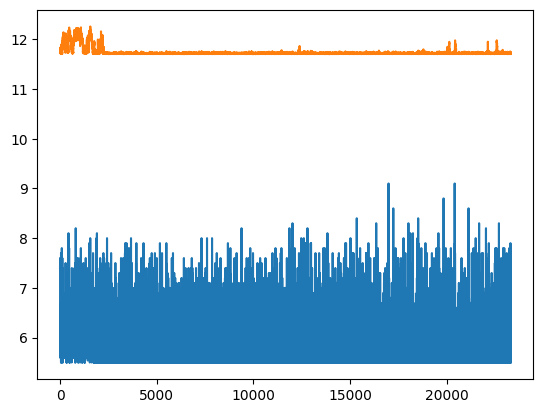

In [ ]:
# plot baseline and predictions
plt.plot(trainY,label='real flood')
plt.plot(2*trainPredict,label='prediction')
plt.show()

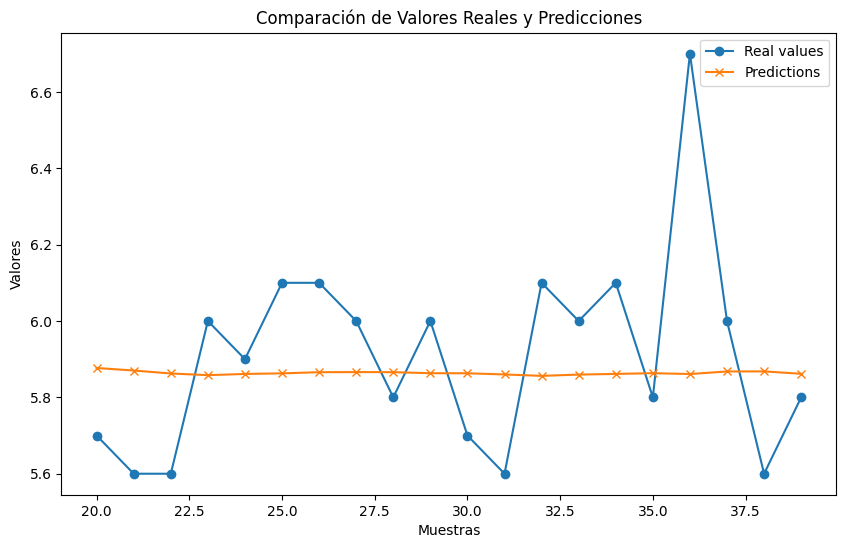

In [ ]:
def graficar_valores(reales, predicciones, inicio, fin):
    """
    Graficar los valores reales y predicciones en el rango especificado.

    Args:
        reales (array): Valores reales.
        predicciones (array): Valores predichos.
        inicio (int): Índice de inicio.
        fin (int): Índice de fin.
    """
    if inicio < 0 or fin > len(reales) or fin > len(predicciones):
        raise ValueError("El rango especificado está fuera de los límites del array.")

    # Seleccionar el rango de valores
    reales_seleccionados = reales[inicio:fin]
    predicciones_seleccionadas = predicciones[inicio:fin]
    indices = np.arange(inicio, fin)

    # Crear la gráfica
    plt.figure(figsize=(10, 6))
    plt.plot(indices, reales_seleccionados, label="Real values", marker='o')
    plt.plot(indices, predicciones_seleccionadas, label="Predictions", marker='x')
    plt.xlabel("Muestras")
    plt.ylabel("Valores")
    plt.title("Comparación de Valores Reales y Predicciones")
    plt.legend()
    plt.show()

# Ejemplo: Graficar del índice 20 al 40
graficar_valores(trainY, trainPredict, 20, 40)


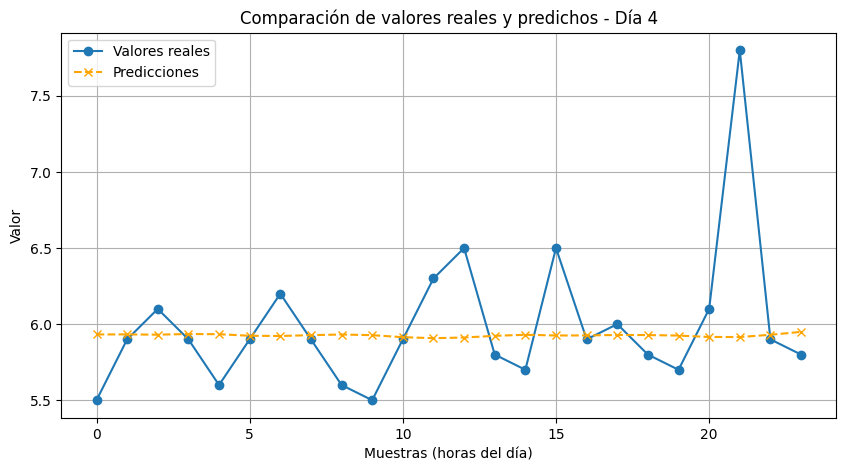

In [ ]:
dia = 3  # puedes cambiar el número del día que quieres visualizar
muestras_por_dia = 24
inicio = dia * muestras_por_dia
fin = inicio + muestras_por_dia

# Extraer los datos del día seleccionado
valores_reales_dia = trainY[inicio:fin]
valores_predichos_dia = trainPredict[inicio:fin]

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(valores_reales_dia, label='Valores reales', marker='o')
plt.plot(valores_predichos_dia, label='Predicciones', marker='x', linestyle='--', color='orange')
plt.title(f'Comparación de valores reales y predichos - Día {dia+1}')
plt.xlabel('Muestras (horas del día)')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()